In [3]:
import os
import pandas as pd
from pathlib import Path

SHARED_DATADIR = Path(os.environ["SHARED_DATA_DIR"])
DATADIR = SHARED_DATADIR / '8344e4f3-d2ea-44f5-8afa-86d2987543a9' / 'data'

timeseries_dir = os.path.join(DATADIR, "timeseries")

files = os.listdir(timeseries_dir)

# cleaning data

results = []

for file in files:

    data = pd.read_csv(
        os.path.join(timeseries_dir, file),
        parse_dates=[0]
    )
    id = file.split("_")[4]
    data["id"] = id
    data = data[["date", "precipitation", "id"]]  # keeping only necessary columns
    data["water_year"] = data["date"].dt.year.astype("int64")  # making sure water_year is the correct format
    data.loc[data["date"].dt.month >= 10, "water_year"] += 1
    counts = (
            data.groupby("water_year")["precipitation"]
                .count()
        )
    valid_years = counts[counts >= 0.95 * 365].index
    data = data[data["water_year"].isin(valid_years)]  # removing years with less than 95% data

    results.append(data)

data = pd.concat(results).reset_index(drop=True)

year_counts = data.groupby("id")["water_year"].nunique()
id_20_years = year_counts[year_counts >= 20].index
data = data[data["id"].isin(id_20_years)]  # only keeping catchments with 20 or more years of data

metadata = pd.read_csv(
    os.path.join(DATADIR, "CAMELS_GB_topographic_attributes.csv")  # adding the spatial data to the timeseries data
)

metadata["gauge_id"] = metadata["gauge_id"].astype(str)

spatial = (
    data
    .groupby("id")["precipitation"]
    .mean()
    .reset_index()
)

spatial = spatial.merge(
    metadata,
    left_on="id",
    right_on="gauge_id"
)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 671 entries, 0 to 670
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              671 non-null    object 
 1   precipitation   671 non-null    float64
 2   gauge_id        671 non-null    object 
 3   gauge_name      671 non-null    object 
 4   gauge_lat       671 non-null    float64
 5   gauge_lon       671 non-null    float64
 6   gauge_easting   671 non-null    int64  
 7   gauge_northing  671 non-null    int64  
 8   gauge_elev      671 non-null    float64
 9   area            671 non-null    float64
 10  dpsbar          669 non-null    float64
 11  elev_mean       669 non-null    float64
 12  elev_min        671 non-null    float64
 13  elev_10         671 non-null    float64
 14  elev_50         671 non-null    float64
 15  elev_90         671 non-null    float64
 16  elev_max        671 non-null    float64
dtypes: float64(12), int64(2), object(3)

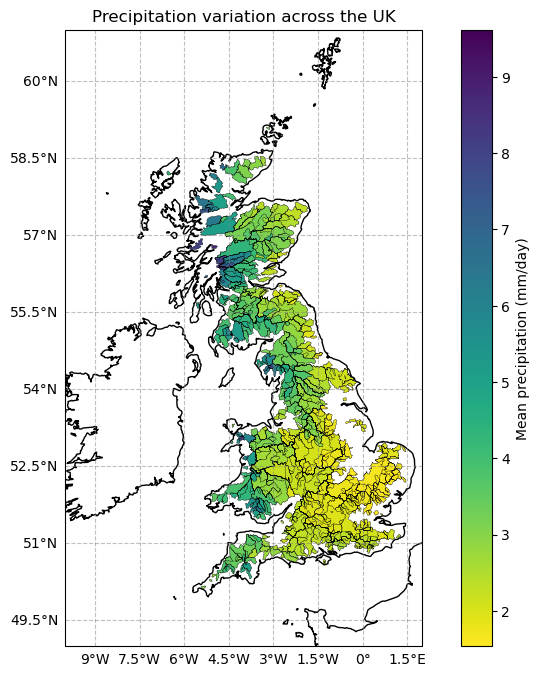

In [39]:
import os
import geopandas as gpd
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


catchments = gpd.read_file(
    os.path.join(DATADIR, "CAMELS_GB_catchment_boundaries.shp")
)

catchments = catchments.to_crs(4326)


catchments = catchments.merge(
    spatial,
    left_on="ID_STRING",
    right_on="id"
)


vmin = catchments["precipitation"].min()
vmax = catchments["precipitation"].max()

fig, ax = plt.subplots(
    figsize=(10,8),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

catchments.plot(
    column="precipitation",
    cmap="viridis_r",       
    legend=False,
    ax=ax,
    transform=ccrs.PlateCarree(),
    vmin=vmin,
    vmax=vmax
)


catchments.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.2,
    transform=ccrs.PlateCarree()
)


ax.coastlines()


ax.set_title("Precipitation variation across the UK")

ax.set_extent([-10, 2, 49, 61], crs=ccrs.PlateCarree())

gl = ax.gridlines(draw_labels=True, linestyle="--",
                  color="gray", alpha=0.5)
gl.top_labels = False
gl.right_labels = False

sm = plt.cm.ScalarMappable(
    cmap="viridis_r",
    norm=mcolors.Normalize(vmin=vmin, vmax=vmax)
)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Mean precipitation (mm/day)")

plt.show()


In [32]:
print(spatial_gdf.crs)

EPSG:27700
